In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pickle

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from xgboost import XGBRegressor

from sklearn.metrics import root_mean_squared_error


In [2]:
features_to_train = ["temp_actual", "temp_6h_actual", "CDH_actual", "HDH_actual", "temp_actual_lag_24h", "Load_lag_24h", "Load_lag_48h", "is_weekend", "is_notable_day"]

train_loc = "../data/processed/day_ahead_train.csv"
test_loc = "../data/processed/day_ahead_test.csv"

df_train = pd.read_csv(train_loc)
df_test = pd.read_csv(test_loc)

In [3]:
with open('../trained_models/day_ahead_linears.pkl', 'rb') as file:
    day_ahead_linears = pickle.load(file)

with open('../trained_models/day_ahead_ridges.pkl', 'rb') as file:
    day_ahead_ridges = pickle.load(file)

with open('../trained_models/day_ahead_lassos.pkl', 'rb') as file:
    day_ahead_lassos = pickle.load(file)

with open('../trained_models/day_ahead_xgbs_best_per_hour_xgbs.pkl', 'rb') as file:
    day_ahead_xgbs_best_per_hour_xgbs = pickle.load(file)

with open('../trained_models/day_ahead_xgbs_best_max_hour_xgbs.pkl', 'rb') as file:
    day_ahead_xgbs_best_max_hour_xgbs = pickle.load(file)

with open('../trained_models/day_ahead_lin_xgbs_best_per_hour_xgbs.pkl', 'rb') as file:
    day_ahead_lin_xgbs_best_per_hour_xgbs = pickle.load(file)

with open('../trained_models/day_ahead_lin_xgbs_best_max_hour_xgbs.pkl', 'rb') as file:
    day_ahead_lin_xgbs_best_max_hour_xgbs = pickle.load(file)


best_per_hour_lin_xgb_hyperparams = pd.read_csv("../src/models/best_per_hour_lin_xgb_hyperparams.csv")
best_max_hour_lin_xgb_hyperparams = pd.read_csv("../src/models/best_max_hour_lin_xgb_hyperparams.csv")
best_per_hour_xgb_hyperparams = pd.read_csv("../src/models/best_per_hour_xgb_hyperparams.csv")
best_max_hour_xgb_hyperparams = pd.read_csv("../src/models/best_max_hour_xgb_hyperparams.csv")

splits_df_loc = "../data/splits/split_bounds.csv"
splits_df = pd.read_csv(splits_df_loc)

ridge_alpha = 32
lasso_alpha = 3.6

In [4]:
def cv_rmse(model_name, input_df):

    match model_name:
        case "linears":
            models = [LinearRegression() for hour in range(0, 24)]
            
        case "ridges":
            models = [Ridge(alpha = ridge_alpha) for hour in range(0, 24)]
            
        case "lassos":
            models = [Lasso(alpha = lasso_alpha) for hour in range(0, 24)]
            
        case "xgb_best_per_hour":
            models = [XGBRegressor(objective='reg:squarederror', 
                                   n_estimators = int(best_per_hour_xgb_hyperparams.iloc[hour]["n_estimators"]), 
                                   learning_rate = best_per_hour_xgb_hyperparams.iloc[hour]["learning_rate"], 
                                   max_depth = int(best_per_hour_xgb_hyperparams.iloc[hour]["max_depth"]), 
                                   min_child_weight = int(best_per_hour_xgb_hyperparams.iloc[hour]["min_child_weight"]), 
                                   subsample = 0.8, 
                                   random_state = 12) 
                      for hour in range(0,24)]
        
        case "xgb_best_max_hour":
            models = [XGBRegressor(objective='reg:squarederror', 
                                   n_estimators = int(best_max_hour_xgb_hyperparams.iloc[0]["n_estimators"]), 
                                   learning_rate = best_max_hour_xgb_hyperparams.iloc[0]["learning_rate"], 
                                   max_depth = int(best_max_hour_xgb_hyperparams.iloc[0]["max_depth"]), 
                                   min_child_weight = int(best_max_hour_xgb_hyperparams.iloc[0]["min_child_weight"]), 
                                   subsample = 0.8, 
                                   random_state = 12) 
                      for hour in range(0,24)]
        case "lin_xgb_best_per_hour":
            lin_models = [LinearRegression() for hour in range(0, 24)]
            
            xgb_models = [XGBRegressor(objective='reg:squarederror', 
                                   n_estimators = int(best_per_hour_lin_xgb_hyperparams.iloc[hour]["n_estimators"]), 
                                   learning_rate = best_per_hour_lin_xgb_hyperparams.iloc[hour]["learning_rate"], 
                                   max_depth = int(best_per_hour_lin_xgb_hyperparams.iloc[hour]["max_depth"]), 
                                   min_child_weight = int(best_per_hour_lin_xgb_hyperparams.iloc[hour]["min_child_weight"]), 
                                   subsample = 0.8, 
                                   random_state = 12) 
                      for hour in range(0,24)]
        case "lin_xgb_best_max_hour":
            lin_models = [LinearRegression() for hour in range(0, 24)]
            
            xgb_models = [XGBRegressor(objective='reg:squarederror', 
                                   n_estimators = int(best_max_hour_lin_xgb_hyperparams.iloc[0]["n_estimators"]), 
                                   learning_rate = best_max_hour_lin_xgb_hyperparams.iloc[0]["learning_rate"], 
                                   max_depth = int(best_max_hour_lin_xgb_hyperparams.iloc[0]["max_depth"]), 
                                   min_child_weight = int(best_max_hour_lin_xgb_hyperparams.iloc[0]["min_child_weight"]), 
                                   subsample = 0.8, 
                                   random_state = 12) 
                      for hour in range(0,24)] 
            
    split_rmses = []
    
    for i in range(1, splits_df.shape[0] + 1):

        split = f"split_{i}"
        row = splits_df[splits_df["split"] == split].iloc[0]

        all_squared_errors = []
            
        for hour in range(0, 24):
            
            train_start_date = row["train_start_date"]
            train_end_date = row["train_end_date"]
            val_start_date = row["val_start_date"]
            val_end_date = row["val_end_date"]
            
            train_mask = (input_df["timestamp"] >= train_start_date) & (input_df["timestamp"] < train_end_date) & (input_df["Hour"] == hour)
            val_mask = (input_df["timestamp"] >= val_start_date) & (input_df["timestamp"] < val_end_date) & (input_df["Hour"] == hour)
            
            X_train = input_df[train_mask].drop(columns=["timestamp", "Load"])
            y_train = input_df[train_mask]["Load"]
            
            X_val = input_df[val_mask].drop(columns=["timestamp", "Load"])
            y_val = input_df[val_mask]["Load"]
            
            if model_name[:7] == "lin_xgb":
                
                n_train_samples = len(X_train)
                initial_len = int(0.6 * n_train_samples)
                step_size = 7
                
                oos_residuals = np.full(n_train_samples, np.nan)
        
                for start in range(initial_len, n_train_samples, step_size):
                    end = min(start + step_size, n_train_samples)
        
                    wf_lin = LinearRegression()
                    wf_lin.fit(X_train.iloc[:start], y_train.iloc[:start])
                
                    preds = wf_lin.predict(X_train.iloc[start:end])
        
                    oos_residuals[start:end] = y_train.iloc[start:end] - preds
        
                mask = ~np.isnan(oos_residuals)
        
                xgb_models[hour].fit(X_train.iloc[mask], oos_residuals[mask])
        
                lin_models[hour].fit(X_train, y_train)
            
                y_lin_pred = lin_models[hour].predict(X_val)
                y_xgbr_pred = xgb_models[hour].predict(X_val)
    
                y_pred = y_lin_pred + y_xgbr_pred
                
            else:
                models[hour].fit(X_train, y_train)
                y_pred = models[hour].predict(X_val)
    
            all_squared_errors.extend((y_val - y_pred) ** 2)
        
        split_rmse = np.sqrt(np.mean(all_squared_errors))
        split_rmses.append(split_rmse)
        
    return np.mean(split_rmses), np.std(split_rmses)


In [86]:
def generate_all_predictions(model_name, input_df):
    
    if model_name == "linears":
        models = day_ahead_linears
        is_lin_xgb = False
    elif model_name == "ridges":
        models = day_ahead_ridges
        is_lin_xgb = False
    elif model_name == "lassos":
        models = day_ahead_lassos
        is_lin_xgb = False
    elif model_name == "xgb_best_per_hour":
        models = day_ahead_xgbs_best_per_hour_xgbs
        is_lin_xgb = False
    elif model_name == "xgb_best_max_hour":
        models = day_ahead_xgbs_best_max_hour_xgbs
        is_lin_xgb = False
    elif model_name == "lin_xgb_best_per_hour":
        lin_models = day_ahead_linears
        xgb_models = day_ahead_lin_xgbs_best_per_hour_xgbs
        is_lin_xgb = True
    elif model_name == "lin_xgb_best_max_hour":
        lin_models = day_ahead_linears
        xgb_models = day_ahead_lin_xgbs_best_max_hour_xgbs
        is_lin_xgb = True
    else:
        raise ValueError(f"Invalid model name: {model_name}")

    preds_list = []

    for hour in range(24):
        hour_mask = input_df["Hour"] == hour
        X_hour = input_df.loc[hour_mask].drop(columns=["timestamp", "Load", "Hour"])

        if len(X_hour) == 0:
            continue

        if is_lin_xgb:
            y_pred_hour = lin_models[hour].predict(X_hour) + xgb_models[hour].predict(X_hour)
        else:
            y_pred_hour = models[hour].predict(X_hour)

        preds_hour_df = pd.DataFrame({
            "timestamp": input_df.loc[hour_mask, "timestamp"],
            "prediction": y_pred_hour
        }, index=input_df.loc[hour_mask].index)

        preds_list.append(preds_hour_df)

    all_preds_df = pd.concat(preds_list)
    all_preds_df = all_preds_df.sort_index()
    return all_preds_df["prediction"]


In [24]:
input_df_train = df_train[["timestamp", "Load", "Hour"] + ["temp_actual", "temp_6h_actual", "CDH_actual", "HDH_actual", "temp_actual_lag_24h", "Load_lag_24h", "Load_lag_48h", "is_weekend", "is_notable_day"]
]
input_df_test = df_test[["timestamp", "Load", "Hour"] + ["temp_actual", "temp_6h_actual", "CDH_actual", "HDH_actual", "temp_actual_lag_24h", "Load_lag_24h", "Load_lag_48h", "is_weekend", "is_notable_day"]
]

model_names = ["linears", "ridges", "lassos", "xgb_best_per_hour", "xgb_best_max_hour", "lin_xgb_best_per_hour", "lin_xgb_best_max_hour"]

errors_dict = {"model_name": model_names, "train_error" : [], "validation_error": [], "validation_std": [], "test_error": [], "test_error_pct_max": []}

max_load_train = input_df_train["Load"].max()
max_load_test = input_df_test["Load"].max()

for model_name in errors_dict["model_name"]:

    train_error = root_mean_squared_error(generate_all_predictions(model_name, input_df_train), input_df_train["Load"])

    validation_error, validation_std = cv_rmse(model_name, input_df_train)
    
    test_errors = []
    
    test_error = root_mean_squared_error(generate_all_predictions(model_name, input_df_test), input_df_test["Load"])
    test_errors.append(test_error)
    
    errors_dict["train_error"].append(train_error)
    errors_dict["validation_error"].append(validation_error)
    errors_dict["validation_std"].append(validation_std)
    errors_dict["test_error"].append(np.mean(test_errors))
    errors_dict["test_error_pct_max"].append(100*np.mean(test_errors)/max_load_test)

errors_df = pd.DataFrame(errors_dict)

In [26]:
errors_df

,model_name,train_error,validation_error,validation_std,test_error,test_error_pct_max
0,linears,148.628481,157.548397,8.835426,156.861845,3.385751
1,ridges,149.602125,159.828714,9.109033,158.315324,3.417123
2,lassos,149.371866,158.067646,8.695638,157.931509,3.408839
3,xgb_best_per_hour,106.150352,148.891497,9.127180,155.903541,3.365067
4,xgb_best_max_hour,102.721747,150.183523,9.230271,155.545488,3.357338
5,lin_xgb_best_per_hour,131.064738,173.880840,18.999788,147.756348,3.189215
6,lin_xgb_best_max_hour,130.746953,174.935766,19.971553,146.997596,3.172838


In [100]:
temp_uncertainties = [i for i in range (1, 11)]

model_names = ["linears", "ridges", "lassos", "xgb_best_per_hour", "xgb_best_max_hour", "lin_xgb_best_per_hour", "lin_xgb_best_max_hour"]

def monte_carlo_temp_sensitivity(
    input_df_test,
    model_names,
    temp_uncertainties,
    n_simulations=100,
    base_t=60,
    filter_fn=None
):
    
    temp_uncertainties_errors_dict = {
        "model_name": [],
        "temp_uncertainty": [],
        "test_error": [],
        "test_std": []
    }
    
    input_df_test["timestamp"] = pd.to_datetime(input_df_test["timestamp"])


    test_df_component_1 = input_df_test[["timestamp", "Load", "Hour"]]
    test_df_component_2 = input_df_test[
        ["temp_actual_lag_24h", "Load_lag_24h", "Load_lag_48h", "is_weekend", "is_notable_day"]
    ]
    

    print("=" * 80)
    print("MONTE CARLO SENSITIVITY ANALYSIS: LOAD FORECAST VS TEMPERATURE UNCERTAINTY")
    print(f"Total Models: {len(model_names)} | Uncertainty Levels: {len(temp_uncertainties)} | Simulations per Level: {n_simulations}")
    print("=" * 80)

    for model_idx, model_name in enumerate(model_names, 1):

        # Model performance on test set with actual temperatures

        if filter_fn is not None:
            mask = filter_fn(input_df_test)
            df_eval = input_df_test.loc[mask]
        else:
            df_eval = input_df_test

        if len(df_eval) == 0:
            continue

        preds = generate_all_predictions(model_name, df_eval)
        test_error_actual = root_mean_squared_error(preds, df_eval["Load"])

        temp_uncertainties_errors_dict["model_name"].append(model_name)
        temp_uncertainties_errors_dict["temp_uncertainty"].append(0)
        temp_uncertainties_errors_dict["test_error"].append(test_error_actual)
        temp_uncertainties_errors_dict["test_std"].append(0.0)

        print("\n" + "-" * 80)
        print(f"[MODEL {model_idx}/{len(model_names)}] Evaluating: {model_name}")
        print("-" * 80)

        for unc_idx, temp_uncertainty in enumerate(temp_uncertainties, 1):

            print(
                f"\n  → Temperature Uncertainty σ = {temp_uncertainty}°F "
                f"({unc_idx}/{len(temp_uncertainties)}) | Running {n_simulations} Monte Carlo sims..."
            )

            temp_uncertainties_errors_dict["model_name"].append(model_name)
            temp_uncertainties_errors_dict["temp_uncertainty"].append(temp_uncertainty)

            rmse_list = []

            for i in range(n_simulations):
                simulated_temp = simulate_long_forecast(
                    input_df_test["temp_actual"],
                    std=temp_uncertainty,
                    correlation_factor=0.5
                )

                test_df_simulated = pd.DataFrame(simulated_temp)
                test_df_simulated["temp_6h_simulated"] = test_df_simulated["temp_simulated"].rolling(6).mean()
                test_df_simulated = test_df_simulated.dropna()

                test_df_simulated["CDH_simulated"] = (test_df_simulated["temp_simulated"] - base_t).clip(lower=0)
                test_df_simulated["HDH_simulated"] = (base_t - test_df_simulated["temp_simulated"]).clip(lower=0)

                valid_index = test_df_simulated.index

                input_df_simulated = pd.concat(
                    [
                        test_df_component_1.loc[valid_index],
                        test_df_simulated,
                        test_df_component_2.loc[valid_index],
                    ],
                    axis=1,
                )

                input_df_simulated = input_df_simulated.rename(
                    columns={
                        "temp_simulated": "temp_actual",
                        "temp_6h_simulated": "temp_6h_actual",
                        "CDH_simulated": "CDH_actual",
                        "HDH_simulated": "HDH_actual",
                    }
                )

                if filter_fn is not None:
                    mask = filter_fn(input_df_simulated)
                    df_eval = input_df_simulated.loc[mask]
                else:
                    df_eval = input_df_simulated

                if len(df_eval) == 0:
                    continue

                preds = generate_all_predictions(model_name, df_eval)
                rmse = root_mean_squared_error(preds, df_eval["Load"])
                rmse_list.append(rmse)

            temp_uncertainties_errors_dict["test_error"].append(np.mean(rmse_list))
            temp_uncertainties_errors_dict["test_std"].append(np.std(rmse_list))

            print(
                f"  ✔ Completed σ = {temp_uncertainty}°F | "
                f"Mean RMSE: {np.mean(rmse_list):.4f} | Std: {np.std(rmse_list):.4f}"
            )

    return pd.DataFrame(temp_uncertainties_errors_dict)


In [102]:
temp_uncertainties_df = monte_carlo_temp_sensitivity(input_df_test, model_names, temp_uncertainties,
    n_simulations=100,
    base_t=60,
    filter_fn=None
)

/var/folders/x5/mt3y0q2n65zcpd0hz503pkx00000gn/T/ipykernel_73648/610575064.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  input_df_test["timestamp"] = pd.to_datetime(input_df_test["timestamp"])


MONTE CARLO SENSITIVITY ANALYSIS: LOAD FORECAST VS TEMPERATURE UNCERTAINTY
Total Models: 7 | Uncertainty Levels: 10 | Simulations per Level: 100

--------------------------------------------------------------------------------
[MODEL 1/7] Evaluating: linears
--------------------------------------------------------------------------------

  → Temperature Uncertainty σ = 1°F (1/10) | Running 100 Monte Carlo sims...
  ✔ Completed σ = 1°F | Mean RMSE: 159.5210 | Std: 0.4457

  → Temperature Uncertainty σ = 2°F (2/10) | Running 100 Monte Carlo sims...
  ✔ Completed σ = 2°F | Mean RMSE: 164.0912 | Std: 0.9766

  → Temperature Uncertainty σ = 3°F (3/10) | Running 100 Monte Carlo sims...
  ✔ Completed σ = 3°F | Mean RMSE: 171.6364 | Std: 1.2676

  → Temperature Uncertainty σ = 4°F (4/10) | Running 100 Monte Carlo sims...
  ✔ Completed σ = 4°F | Mean RMSE: 182.3533 | Std: 1.7198

  → Temperature Uncertainty σ = 5°F (5/10) | Running 100 Monte Carlo sims...
  ✔ Completed σ = 5°F | Mean RMSE: 197

In [106]:
temp_uncertainties_df

,model_name,temp_uncertainty,test_error,test_std
0,linears,0,156.861845,0.000000
1,linears,1,159.520988,0.445733
2,linears,2,164.091217,0.976585
3,linears,3,171.636394,1.267563
4,linears,4,182.353269,1.719773
...,...,...,...,...
72,lin_xgb_best_max_hour,6,248.285767,3.773142
73,lin_xgb_best_max_hour,7,273.672062,4.242720
74,lin_xgb_best_max_hour,8,299.797346,5.048763
75,lin_xgb_best_max_hour,9,325.882910,5.830648


In [108]:
hour_filters = []

for hour in range(0, 24):
    hour_filter = lambda df: df["Hour"] == hour
    hour_filters.append(hour_filter)

In [120]:
hours_df_total = monte_carlo_temp_sensitivity(input_df_test, model_names, temp_uncertainties,
    n_simulations=100,
    base_t=60,
    filter_fn=hour_filters[0]
)

hours_df_total["Hour"] = 0

for hour in range(1, 2):

    hour_df = monte_carlo_temp_sensitivity(input_df_test, model_names, temp_uncertainties, n_simulations=100, base_t=60, filter_fn=hour_filters[hour])

    hour_df["Hour"] = hour

    hours_df_total = pd.concat([hours_df_total, hour_df], axis = 0)


/var/folders/x5/mt3y0q2n65zcpd0hz503pkx00000gn/T/ipykernel_73648/610575064.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  input_df_test["timestamp"] = pd.to_datetime(input_df_test["timestamp"])


MONTE CARLO SENSITIVITY ANALYSIS: LOAD FORECAST VS TEMPERATURE UNCERTAINTY
Total Models: 7 | Uncertainty Levels: 10 | Simulations per Level: 100

--------------------------------------------------------------------------------
[MODEL 1/7] Evaluating: linears
--------------------------------------------------------------------------------

  → Temperature Uncertainty σ = 1°F (1/10) | Running 100 Monte Carlo sims...
  ✔ Completed σ = 1°F | Mean RMSE: 226.8978 | Std: 1.5138

  → Temperature Uncertainty σ = 2°F (2/10) | Running 100 Monte Carlo sims...
  ✔ Completed σ = 2°F | Mean RMSE: 232.7100 | Std: 3.1359

  → Temperature Uncertainty σ = 3°F (3/10) | Running 100 Monte Carlo sims...
  ✔ Completed σ = 3°F | Mean RMSE: 241.0666 | Std: 4.6489

  → Temperature Uncertainty σ = 4°F (4/10) | Running 100 Monte Carlo sims...
  ✔ Completed σ = 4°F | Mean RMSE: 252.1560 | Std: 5.6957

  → Temperature Uncertainty σ = 5°F (5/10) | Running 100 Monte Carlo sims...
  ✔ Completed σ = 5°F | Mean RMSE: 266

/var/folders/x5/mt3y0q2n65zcpd0hz503pkx00000gn/T/ipykernel_73648/610575064.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  input_df_test["timestamp"] = pd.to_datetime(input_df_test["timestamp"])


  ✔ Completed σ = 1°F | Mean RMSE: 96.9328 | Std: 0.7059

  → Temperature Uncertainty σ = 2°F (2/10) | Running 100 Monte Carlo sims...
  ✔ Completed σ = 2°F | Mean RMSE: 98.9348 | Std: 1.6722

  → Temperature Uncertainty σ = 3°F (3/10) | Running 100 Monte Carlo sims...
  ✔ Completed σ = 3°F | Mean RMSE: 101.9709 | Std: 2.1903

  → Temperature Uncertainty σ = 4°F (4/10) | Running 100 Monte Carlo sims...
  ✔ Completed σ = 4°F | Mean RMSE: 105.9993 | Std: 2.7073

  → Temperature Uncertainty σ = 5°F (5/10) | Running 100 Monte Carlo sims...
  ✔ Completed σ = 5°F | Mean RMSE: 110.6865 | Std: 3.2835

  → Temperature Uncertainty σ = 6°F (6/10) | Running 100 Monte Carlo sims...
  ✔ Completed σ = 6°F | Mean RMSE: 115.1753 | Std: 3.7023

  → Temperature Uncertainty σ = 7°F (7/10) | Running 100 Monte Carlo sims...
  ✔ Completed σ = 7°F | Mean RMSE: 120.6780 | Std: 4.1221

  → Temperature Uncertainty σ = 8°F (8/10) | Running 100 Monte Carlo sims...
  ✔ Completed σ = 8°F | Mean RMSE: 126.5545 | Std:

In [ ]:
summer_months = [6, 7, 8]

summer_filter = lambda df: df["timestamp"].dt.month.isin(summer_months)

winter_months = [11, 12, 1, 2]

winter_filter = lambda df: df["timestamp"].dt.month.isin(winter_months)

winter_df = monte_carlo_temp_sensitivity(input_df_test, model_names, temp_uncertainties,
    n_simulations=100,
    base_t=60,
    filter_fn=winter_filter
)

winter_df["Season"] = "Winter"

summer_df = monte_carlo_temp_sensitivity(input_df_test, model_names, temp_uncertainties,
    n_simulations=100,
    base_t=60,
    filter_fn=summer_filter
)

summer_df["Season"] = "Summer"


seasonal_test_df = pd.concat([winter_df, summer_df], axis = 0)



In [ ]:
weekend_filter = lambda df: df["is_weekend"] == 1

weekday_filter = lambda df: df["is_weekend"] == 0

weekend_df = monte_carlo_temp_sensitivity(input_df_test, model_names, temp_uncertainties,
    n_simulations=100,
    base_t=60,
    filter_fn=weekend_filter
)

summer_df["is_weekend"] = 1

weekday_df = monte_carlo_temp_sensitivity(input_df_test, model_names, temp_uncertainties,
    n_simulations=100,
    base_t=60,
    filter_fn=weekday_filter
)

summer_df["is_weekend"] = 0

weekday_weekend_test_df = pd.concat([weekend_df, weekday_df], axis = 0)



In [ ]:
top_10_pct_load_filter = lambda df: df["Load"] >= df["Load"].quantile(90)

top_10_pct_load_df = monte_carlo_temp_sensitivity(input_df_test, model_names, temp_uncertainties,
    n_simulations=100,
    base_t=60,
    filter_fn=top_10_pct_load_filter
)

In [202]:
top_10_pct_load_df = pd.read_csv("../data/results/day_ahead_temp_uncertainty_filter_top_10_pct_load.csv")
test_rmse = pd.read_csv("../data/results/day_ahead_temp_uncertainty_filter_none.csv")

season_df = pd.read_csv("../data/results/day_ahead_temp_uncertainty_filter_season.csv")

hour_df = pd.read_csv("../data/results/day_ahead_temp_uncertainty_filter_hour.csv")


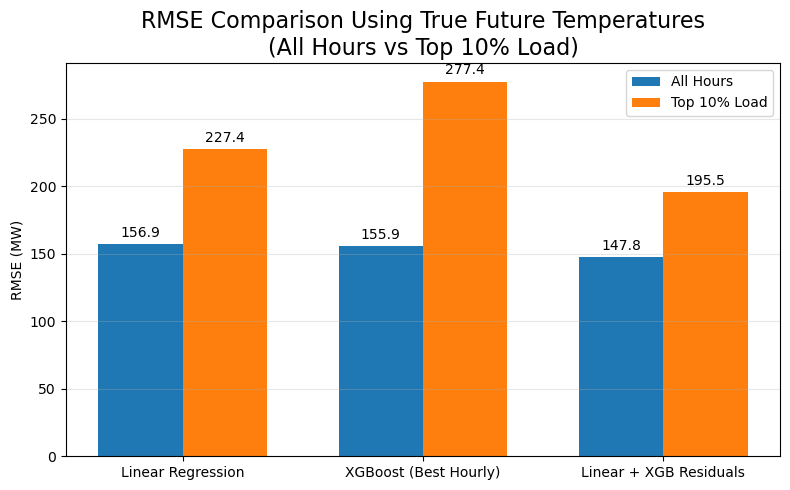

In [302]:
import matplotlib.pyplot as plt
import numpy as np

# Models to plot
model_class_names = ["linears", "xgb_best_per_hour", "lin_xgb_best_per_hour"]
model_class_titles = {
    "linears": "Linear Regression",
    "xgb_best_per_hour": "XGBoost (Best Hourly)",
    "lin_xgb_best_per_hour": "Linear + XGB Residuals"
}

# Prepare data
total_rmse_vals = []
top10_rmse_vals = []

for model_name in model_class_names:
    # Baseline RMSE for temp_uncertainty = 0
    baseline_total_row = total_df_rel[
        (total_df_rel['model_name'] == model_name) & 
        (total_df_rel['temp_uncertainty'] == 0)
    ]
    if not baseline_total_row.empty:
        baseline_total = baseline_total_row['test_error'].iloc[0]
    else:
        print(f"No baseline total RMSE found for {model_name}")
        baseline_total = np.nan

    baseline_top10_row = top10_df_rel[
        (top10_df_rel['model_name'] == model_name) & 
        (top10_df_rel['temp_uncertainty'] == 0)
    ]
    if not baseline_top10_row.empty:
        baseline_top10 = baseline_top10_row['test_error'].iloc[0]
    else:
        print(f"No baseline top 10% RMSE found for {model_name}")
        baseline_top10 = np.nan

    # Append to lists
    total_rmse_vals.append(baseline_total)
    top10_rmse_vals.append(baseline_top10)

# Bar positions
x = np.arange(len(model_class_names))
width = 0.35

fig, ax = plt.subplots(figsize=(8,5))

# Plot bars
bars_total = ax.bar(x - width/2, total_rmse_vals, width, label='All Hours')
bars_top10 = ax.bar(x + width/2, top10_rmse_vals, width, label='Top 10% Load')

# Labels and formatting
ax.set_ylabel('RMSE (MW)')
ax.set_title("RMSE Comparison Using True Future Temperatures\n(All Hours vs Top 10% Load)", fontsize=title_font)
ax.set_xticks(x)
ax.set_xticklabels([model_class_titles[m] for m in model_class_names])
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Annotate bars with values
for b in bars_total + bars_top10:
    height = b.get_height()
    ax.annotate(f'{height:.1f}',
                xy=(b.get_x() + b.get_width()/2, height),
                xytext=(0,3),
                textcoords="offset points",
                ha='center', va='bottom')

plt.tight_layout()
plt.show()

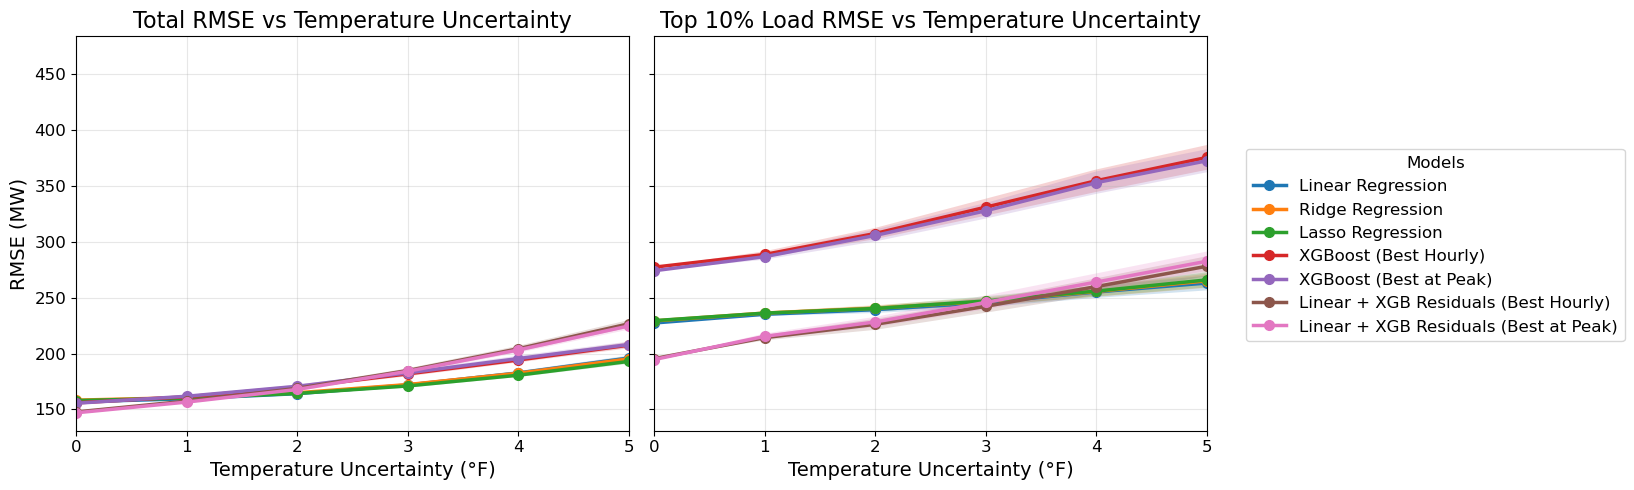

In [300]:
import pandas as pd
import matplotlib.pyplot as plt

# Font and line settings (match seasonal plot)
title_font = 16
label_font = 14
tick_font = 12
legend_font = 12
line_width = 2.5
marker_size = 7
alpha_std = 0.2  # transparency for std shading

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)

for model_name in model_names:
    
    # Total RMSE with std
    total_df = (
        test_rmse[test_rmse["model_name"] == model_name]
        [["temp_uncertainty", "test_error", "test_std"]]
        .rename(columns={"test_error":"total_rmse", "test_std":"total_std"})
        .copy()
    )
    
    # Top 10% RMSE with std
    top_10_df = (
        top_10_pct_load_df[top_10_pct_load_df["model_name"] == model_name]
        [["temp_uncertainty", "test_error", "test_std"]]
        .rename(columns={"test_error":"top_10_rmse", "test_std":"top_10_std"})
        .copy()
    )
    
    label = model_name_to_title_dict[model_name]
    
    # Left plot: Total RMSE
    axes[0].plot(
        total_df["temp_uncertainty"], total_df["total_rmse"], 
        marker="o", markersize=marker_size, linewidth=line_width, label=label
    )
    axes[0].fill_between(
        total_df["temp_uncertainty"],
        total_df["total_rmse"] - total_df["total_std"],
        total_df["total_rmse"] + total_df["total_std"],
        alpha=alpha_std
    )
    
    # Right plot: Top 10% RMSE
    axes[1].plot(
        top_10_df["temp_uncertainty"], top_10_df["top_10_rmse"], 
        marker="o", markersize=marker_size, linewidth=line_width, label=label
    )
    axes[1].fill_between(
        top_10_df["temp_uncertainty"],
        top_10_df["top_10_rmse"] - top_10_df["top_10_std"],
        top_10_df["top_10_rmse"] + top_10_df["top_10_std"],
        alpha=alpha_std
    )

# Formatting
axes[0].set_title("Total RMSE vs Temperature Uncertainty", fontsize=title_font)
axes[0].set_xlabel("Temperature Uncertainty (°F)", fontsize=label_font)
axes[0].set_ylabel("RMSE (MW)", fontsize=label_font)
axes[0].set_xlim(0, 5)
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(axis='both', labelsize=tick_font)

axes[1].set_title("Top 10% Load RMSE vs Temperature Uncertainty", fontsize=title_font)
axes[1].set_xlabel("Temperature Uncertainty (°F)", fontsize=label_font)
axes[1].set_xlim(0, 5)
axes[1].grid(True, alpha=0.3)
axes[1].tick_params(axis='both', labelsize=tick_font)

# Shared legend outside the plots
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="center right",
    bbox_to_anchor=(1.17, 0.5),
    title="Models",
    fontsize=legend_font,
    title_fontsize=legend_font
)

plt.tight_layout(rect=[0, 0, 0.88, 1])
plt.show()

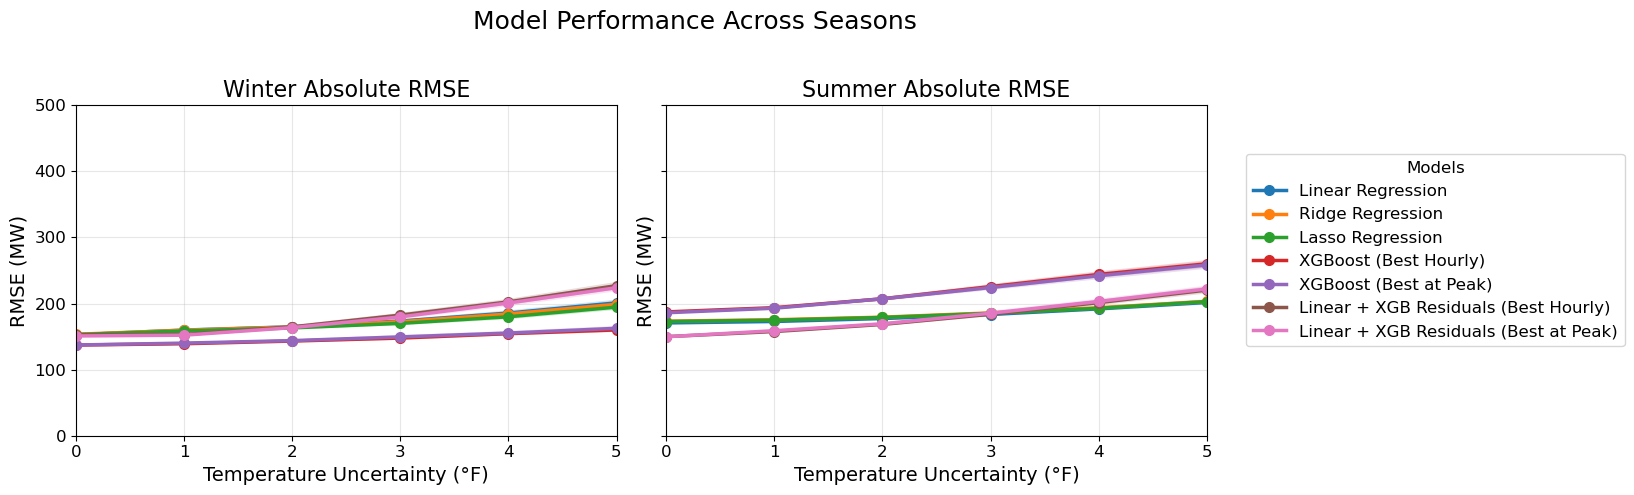

In [298]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14,5), sharey=True)

# Font and line settings
title_font = 16
label_font = 14
tick_font = 12
legend_font = 12
line_width = 2.5
marker_size = 7
alpha_std = 0.2  # transparency for std shading

for i, season_key in enumerate(['Winter', 'Summer']):
    ax = axes[i]
    df_slice = season_df[season_df['Season']==season_key]  # absolute RMSE
    
    for model_name in model_names:
        model_df = df_slice[df_slice['model_name']==model_name].sort_values('temp_uncertainty')
        
        # Plot mean RMSE
        ax.plot(
            model_df['temp_uncertainty'],
            model_df['test_error'],
            marker='o',
            markersize=marker_size,
            linewidth=line_width,
            label=model_name_to_title_dict[model_name]
        )
        
        # Plot ±1 std shading
        ax.fill_between(
            model_df['temp_uncertainty'],
            model_df['test_error'] - model_df['test_std'],
            model_df['test_error'] + model_df['test_std'],
            alpha=alpha_std
        )
    
    ax.set_title(f"{season_key} Absolute RMSE", fontsize=title_font)
    ax.set_xlabel("Temperature Uncertainty (°F)", fontsize=label_font)
    ax.set_ylabel("RMSE (MW)", fontsize=label_font)
    ax.set_ylim(0, 500)
    ax.set_xlim(0, 5)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='both', labelsize=tick_font)

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc='center right',
    bbox_to_anchor=(1.17, 0.5),
    title='Models',
    fontsize=legend_font,
    title_fontsize=legend_font
)

plt.suptitle("Model Performance Across Seasons", fontsize=title_font+2)
plt.tight_layout(rect=[0,0,0.88,0.95])
plt.show()

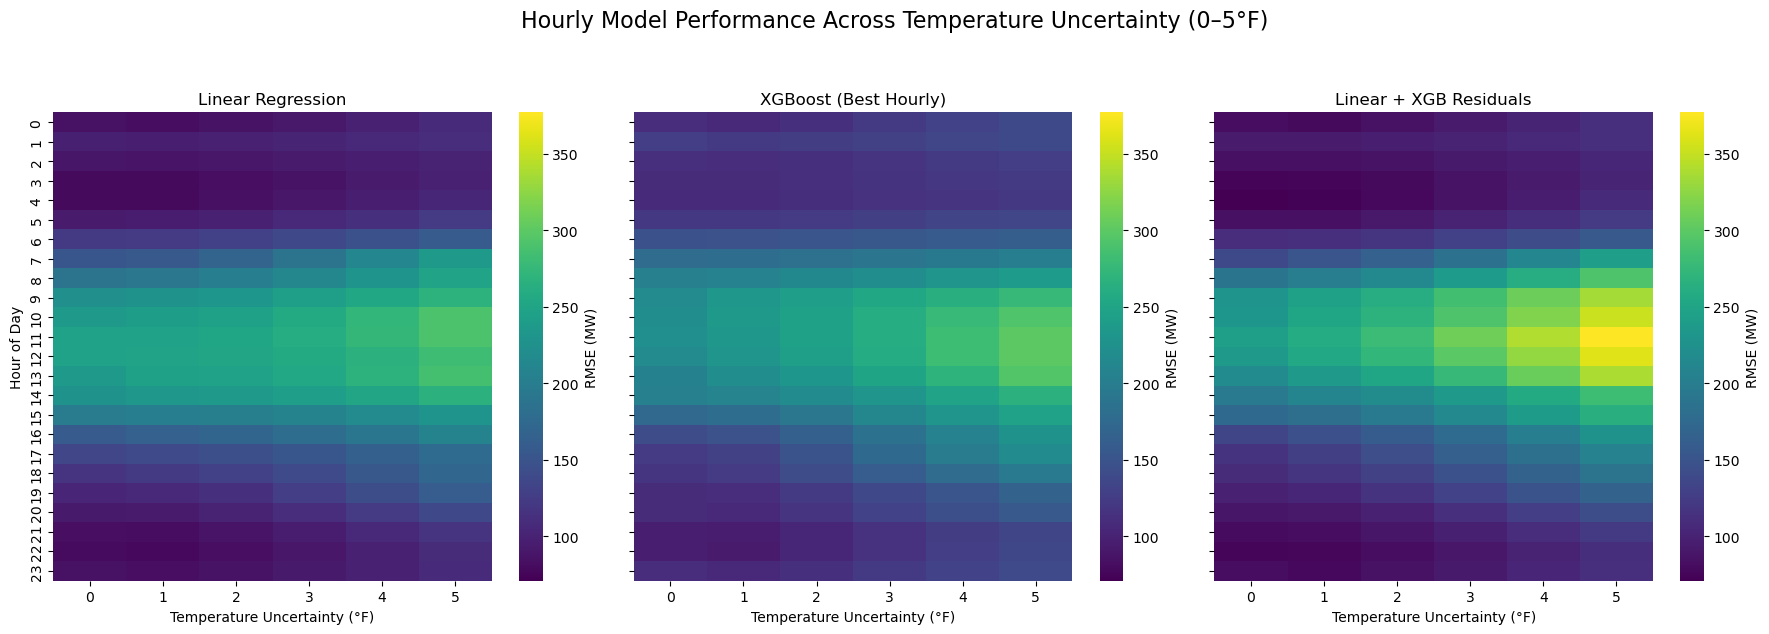

In [250]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Read the data
hour_df = pd.read_csv("../data/results/day_ahead_temp_uncertainty_filter_hour.csv")

# Representative model classes
model_class_names = ["linears", "xgb_best_per_hour", "lin_xgb_best_per_hour"]
model_class_titles = {
    "linears": "Linear Regression",
    "xgb_best_per_hour": "XGBoost (Best Hourly)",
    "lin_xgb_best_per_hour": "Linear + XGB Residuals"
}

# Filter for realistic temp uncertainty (0–5°F)
hour_df_filtered = hour_df[hour_df['temp_uncertainty'] <= 5]

# Compute global min and max RMSE for consistent colorbar
vmin = hour_df_filtered['test_error'].min()
vmax = hour_df_filtered['test_error'].max()

# Plot one heatmap per model class
fig, axes = plt.subplots(1, len(model_class_names), figsize=(18,6), sharey=True)

for i, model_name in enumerate(model_class_names):
    ax = axes[i]
    df_model = hour_df_filtered[hour_df_filtered['model_name']==model_name].copy()
    
    # Pivot: rows=Hour (0-23), columns=temp_uncertainty, values=RMSE
    heatmap_data = df_model.pivot(index='Hour', columns='temp_uncertainty', values='test_error')
    
    sns.heatmap(
        heatmap_data, 
        ax=ax,
        cmap='viridis',
        annot=False,  # No numbers
        vmin=vmin, vmax=vmax,  # Same color scale for all models
        cbar_kws={'label':'RMSE (MW)'}
    )
    
    ax.set_title(model_class_titles[model_name])
    ax.set_xlabel("Temperature Uncertainty (°F)")
    if i == 0:
        ax.set_ylabel("Hour of Day")
    else:
        ax.set_ylabel("")

plt.suptitle("Hourly Model Performance Across Temperature Uncertainty (0–5°F)", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

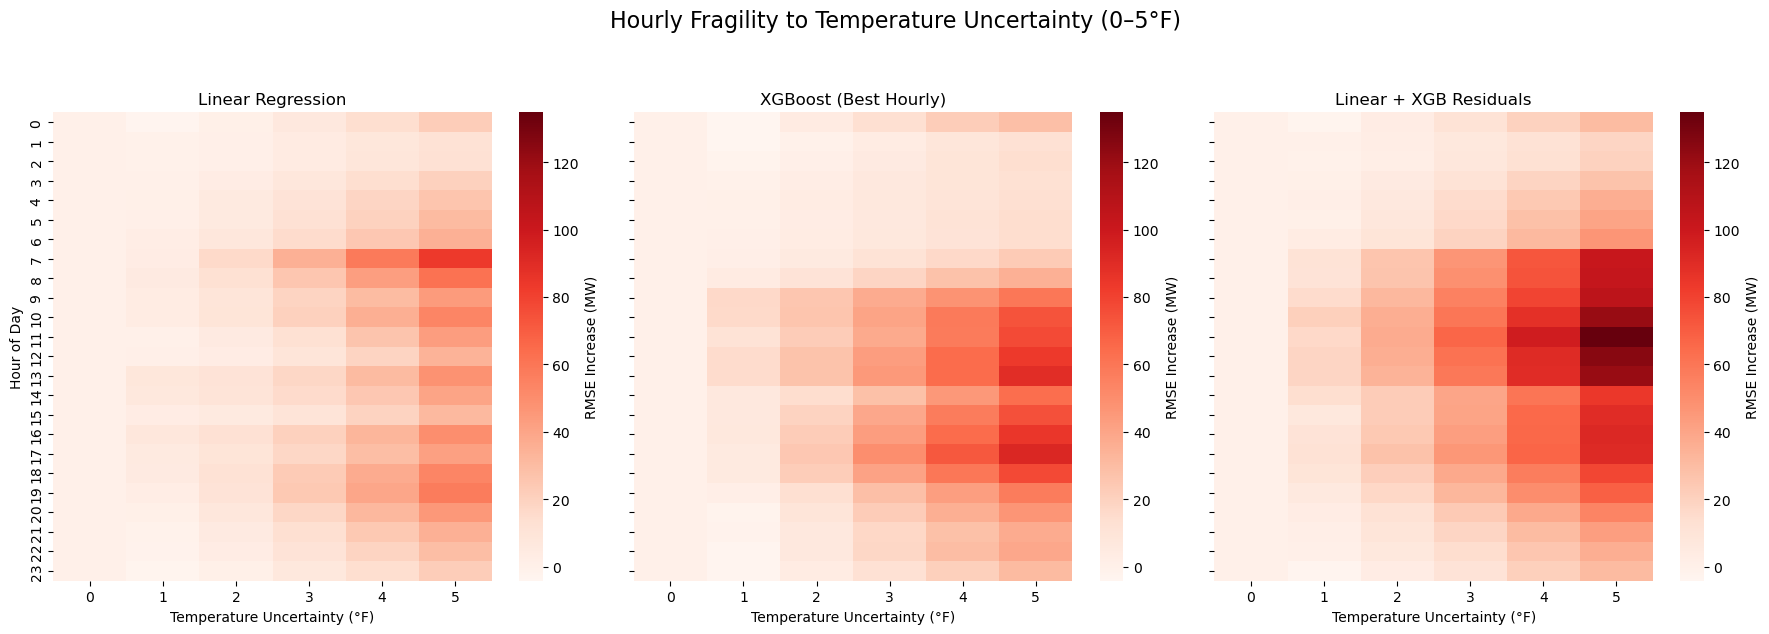

In [248]:
import matplotlib.pyplot as plt
import seaborn as sns

model_class_names = ["linears", "xgb_best_per_hour", "lin_xgb_best_per_hour"]
model_class_titles = {
    "linears": "Linear Regression",
    "xgb_best_per_hour": "XGBoost (Best Hourly)",
    "lin_xgb_best_per_hour": "Linear + XGB Residuals"
}

# Filter for realistic temp uncertainty (<=5°F)
hour_rel_df_filtered = hour_rel_df[hour_rel_df['temp_uncertainty'] <= 5]

# Compute global min and max RMSE increase for consistent color scale
vmin = hour_rel_df_filtered['rmse_increase'].min()
vmax = hour_rel_df_filtered['rmse_increase'].max()

fig, axes = plt.subplots(1, len(model_class_names), figsize=(18,6), sharey=True)

for i, model_name in enumerate(model_class_names):
    ax = axes[i]
    df_model = hour_rel_df_filtered[hour_rel_df_filtered['model_name']==model_name].copy()
    
    # Pivot: rows=Hour, columns=temp_uncertainty, values=RMSE increase
    heatmap_data = df_model.pivot(index='Hour', columns='temp_uncertainty', values='rmse_increase')
    
    sns.heatmap(
        heatmap_data, 
        ax=ax,
        cmap='Reds',  # red = more fragile
        annot=False,
        vmin=vmin, vmax=vmax,  # SAME scale for all subplots
        cbar_kws={'label':'RMSE Increase (MW)'}
    )
    
    ax.set_title(model_class_titles[model_name])
    ax.set_xlabel("Temperature Uncertainty (°F)")
    if i == 0:
        ax.set_ylabel("Hour of Day")
    else:
        ax.set_ylabel("")

plt.suptitle("Hourly Fragility to Temperature Uncertainty (0–5°F)", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

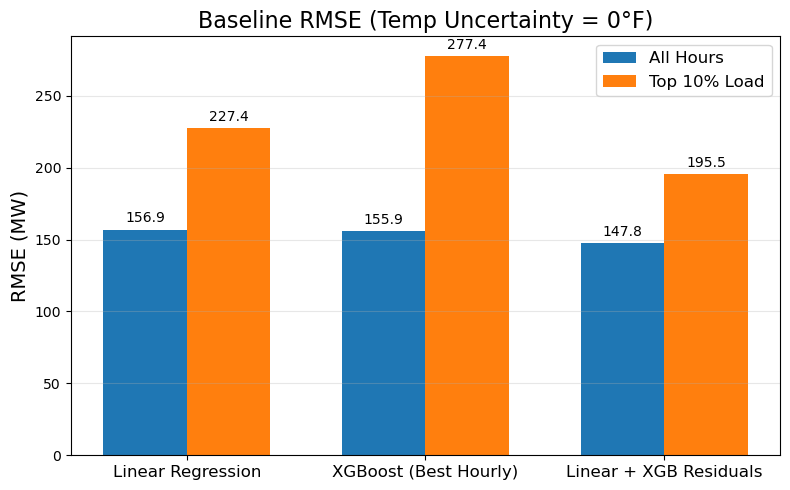

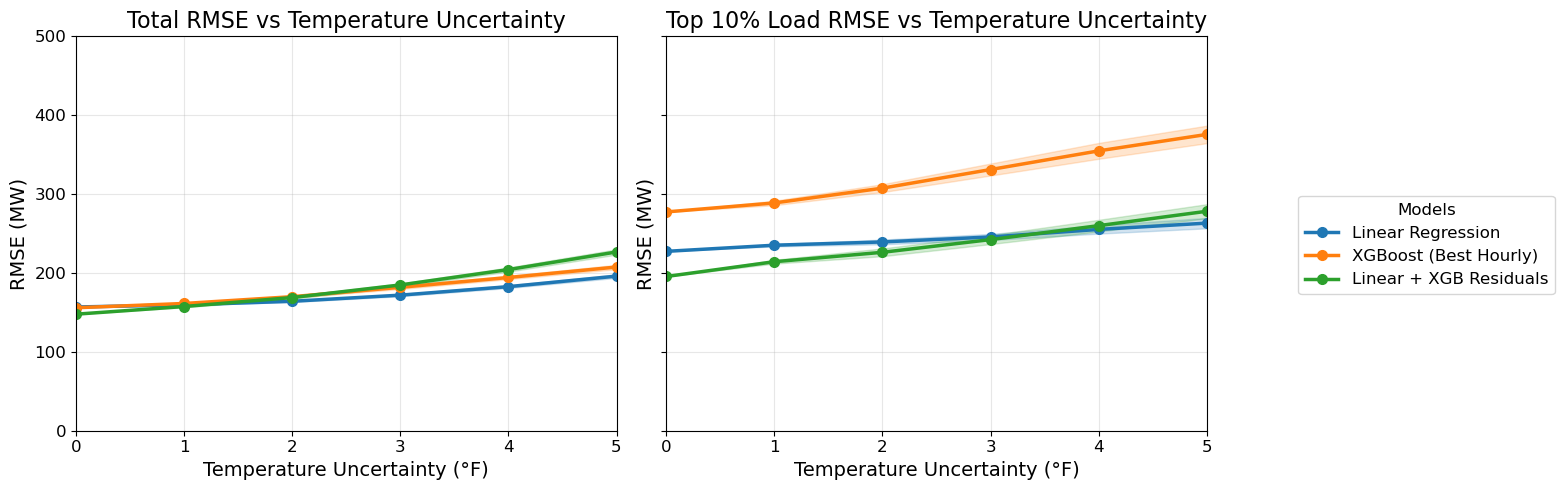

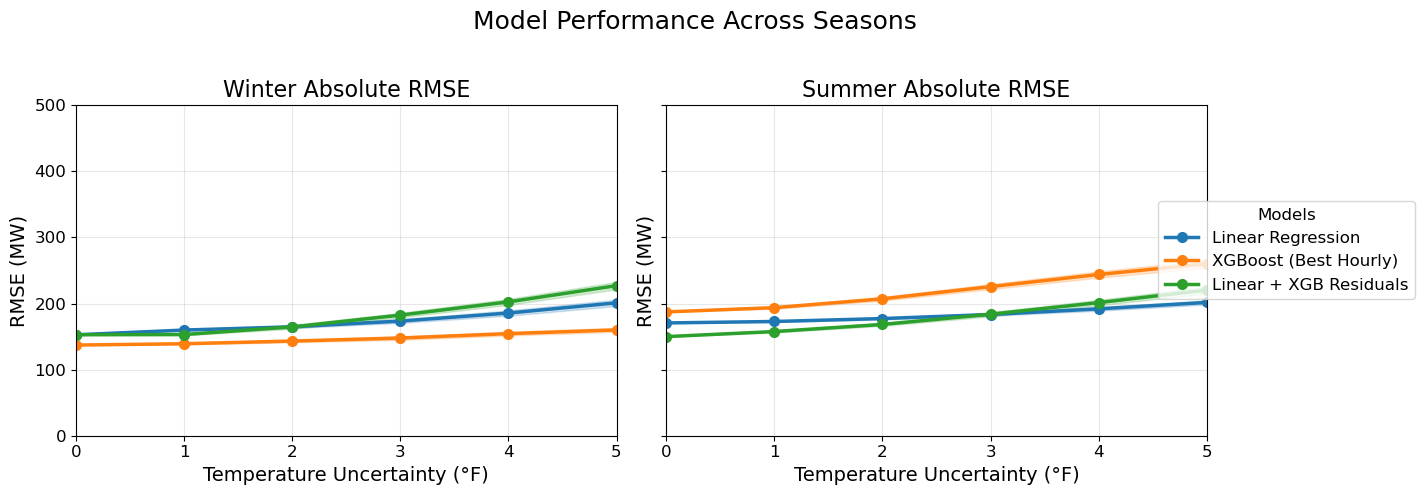

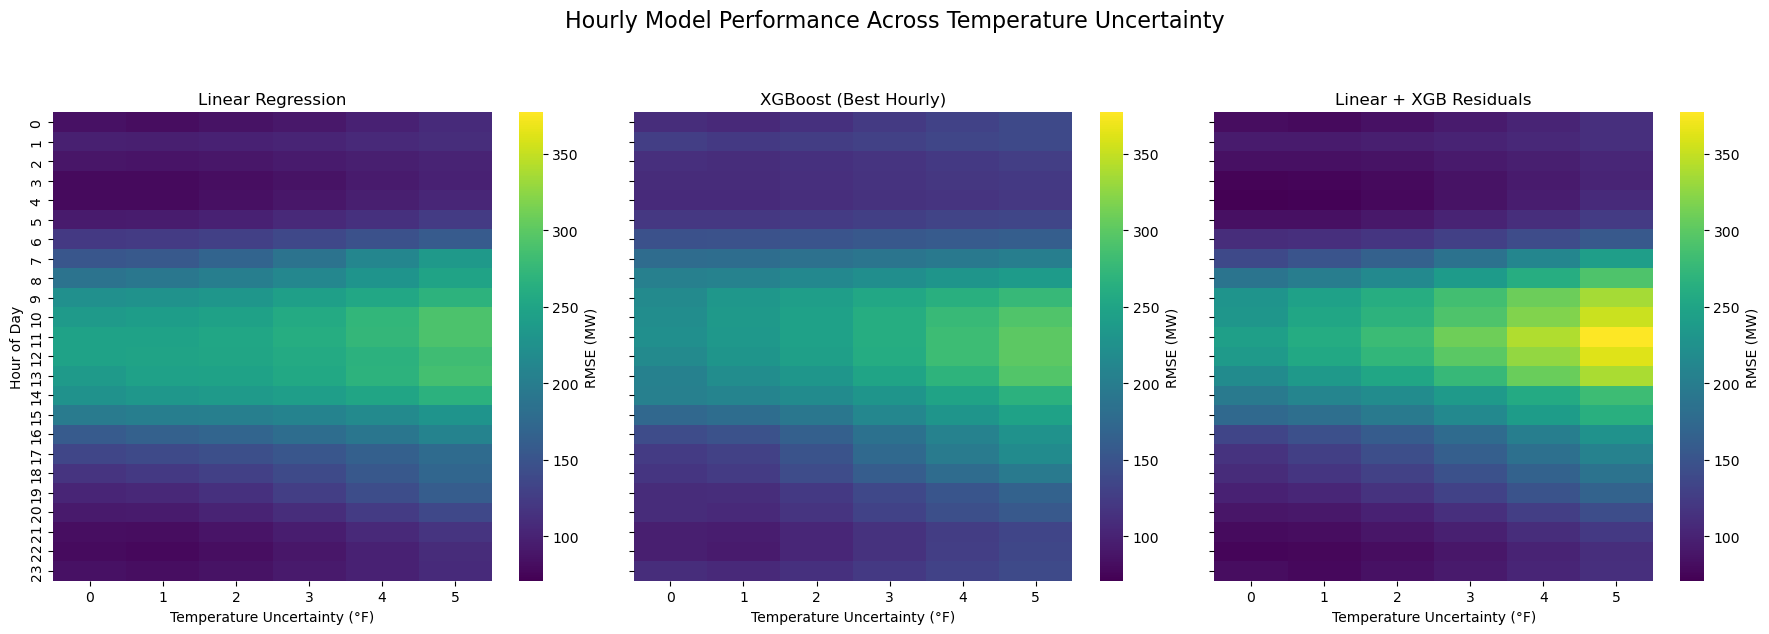

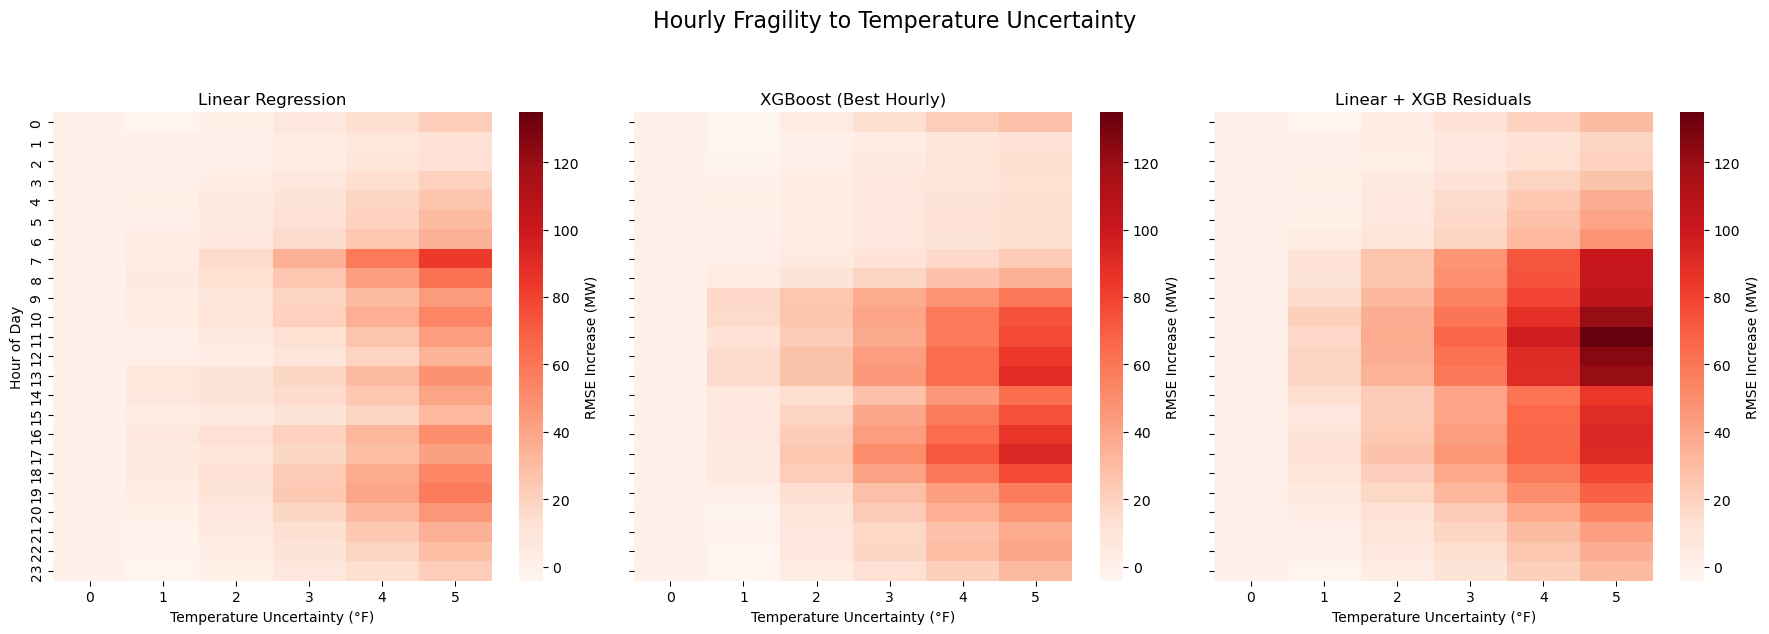

In [276]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load data
top_10_pct_load_df = pd.read_csv("../data/results/day_ahead_temp_uncertainty_filter_top_10_pct_load.csv")
test_rmse = pd.read_csv("../data/results/day_ahead_temp_uncertainty_filter_none.csv")
season_df = pd.read_csv("../data/results/day_ahead_temp_uncertainty_filter_season.csv")
hour_df = pd.read_csv("../data/results/day_ahead_temp_uncertainty_filter_hour.csv")
hour_rel_df = hour_df.copy()  # assuming you computed rmse_increase previously

# ------------------------
# Settings (unified)
# ------------------------
model_class_names = ["linears", "xgb_best_per_hour", "lin_xgb_best_per_hour"]
model_class_titles = {
    "linears": "Linear Regression",
    "xgb_best_per_hour": "XGBoost (Best Hourly)",
    "lin_xgb_best_per_hour": "Linear + XGB Residuals"
}

# Plot appearance
title_font = 16
label_font = 14
tick_font = 12
legend_font = 12
line_width = 2.5
marker_size = 7
alpha_std = 0.2
temp_unc_limit = 5  # °F

# Unified color palette
palette = sns.color_palette("tab10", n_colors=len(model_class_names))

# ------------------------
# 1️⃣ Baseline RMSE Bar Plot
# ------------------------
# Colors for bar sets
bar_colors = ['#1f77b4', '#ff7f0e']  # blue for total, orange for top 10%

total_rmse_vals = []
top10_rmse_vals = []

for model_name in model_class_names:
    # All hours
    baseline_total_row = test_rmse[(test_rmse['model_name']==model_name) & (test_rmse['temp_uncertainty']==0)]
    baseline_total = baseline_total_row['test_error'].iloc[0] if not baseline_total_row.empty else np.nan
    total_rmse_vals.append(baseline_total)
    
    # Top 10%
    baseline_top10_row = top_10_pct_load_df[(top_10_pct_load_df['model_name']==model_name) & (top_10_pct_load_df['temp_uncertainty']==0)]
    baseline_top10 = baseline_top10_row['test_error'].iloc[0] if not baseline_top10_row.empty else np.nan
    top10_rmse_vals.append(baseline_top10)

x = np.arange(len(model_class_names))
width = 0.35

fig, ax = plt.subplots(figsize=(8,5))

# Assign a single color per bar set
bars_total = ax.bar(x - width/2, total_rmse_vals, width, label='All Hours', color=bar_colors[0])
bars_top10 = ax.bar(x + width/2, top10_rmse_vals, width, label='Top 10% Load', color=bar_colors[1])

ax.set_ylabel('RMSE (MW)', fontsize=label_font)
ax.set_title('Baseline RMSE (Temp Uncertainty = 0°F)', fontsize=title_font)
ax.set_xticks(x)
ax.set_xticklabels([model_class_titles[m] for m in model_class_names], fontsize=tick_font)
ax.legend(fontsize=legend_font)
ax.grid(axis='y', alpha=0.3)

# Annotate bars
for b in bars_total + bars_top10:
    height = b.get_height()
    ax.annotate(f'{height:.1f}',
                xy=(b.get_x() + b.get_width()/2, height),
                xytext=(0,3),
                textcoords="offset points",
                ha='center', va='bottom')

plt.tight_layout()
plt.show()

# ------------------------
# 2️⃣ Total vs Top 10% RMSE vs Temp Uncertainty
# ------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)

for i, (rmse_df, title) in enumerate([(test_rmse, "Total RMSE"), (top_10_pct_load_df, "Top 10% Load RMSE")]):
    ax = axes[i]
    for j, model_name in enumerate(model_class_names):
        df = rmse_df[rmse_df['model_name']==model_name].copy()
        df = df[df['temp_uncertainty']<=temp_unc_limit].sort_values('temp_uncertainty')
        ax.plot(df['temp_uncertainty'], df['test_error'],
                marker='o', linewidth=line_width, markersize=marker_size,
                color=palette[j], label=model_class_titles[model_name])
        if 'test_std' in df.columns:
            ax.fill_between(df['temp_uncertainty'],
                            df['test_error'] - df['test_std'],
                            df['test_error'] + df['test_std'],
                            alpha=alpha_std, color=palette[j])
    ax.set_title(f"{title} vs Temperature Uncertainty", fontsize=title_font)
    ax.set_xlabel("Temperature Uncertainty (°F)", fontsize=label_font)
    ax.set_ylabel("RMSE (MW)", fontsize=label_font)
    ax.set_xlim(0, temp_unc_limit)
    ax.set_ylim(0, 500)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='both', labelsize=tick_font)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center right', bbox_to_anchor=(1.12, 0.5),
           title='Models', fontsize=legend_font, title_fontsize=legend_font)
plt.tight_layout(rect=[0,0,0.88,1])
plt.show()

# ------------------------
# 3️⃣ Seasonal Absolute RMSE
# ------------------------
fig, axes = plt.subplots(1, 2, figsize=(14,5), sharey=True)

for i, season_key in enumerate(['Winter','Summer']):
    ax = axes[i]
    df_slice = season_df[season_df['Season']==season_key]
    for j, model_name in enumerate(model_class_names):
        df = df_slice[df_slice['model_name']==model_name].copy()
        df = df[df['temp_uncertainty']<=temp_unc_limit].sort_values('temp_uncertainty')
        ax.plot(df['temp_uncertainty'], df['test_error'],
                marker='o', linewidth=line_width, markersize=marker_size,
                color=palette[j], label=model_class_titles[model_name])
        if 'test_std' in df.columns:
            ax.fill_between(df['temp_uncertainty'],
                            df['test_error'] - df['test_std'],
                            df['test_error'] + df['test_std'],
                            alpha=alpha_std, color=palette[j])
    ax.set_title(f"{season_key} Absolute RMSE", fontsize=title_font)
    ax.set_xlabel("Temperature Uncertainty (°F)", fontsize=label_font)
    ax.set_ylabel("RMSE (MW)", fontsize=label_font)
    ax.set_xlim(0, temp_unc_limit)
    ax.set_ylim(0, 500)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='both', labelsize=tick_font)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center right', bbox_to_anchor=(1.02, 0.5),
           title='Models', fontsize=legend_font, title_fontsize=legend_font)
plt.suptitle("Model Performance Across Seasons", fontsize=title_font+2)
plt.tight_layout(rect=[0,0,0.88,0.95])
plt.show()

# ------------------------
# 4️⃣ Hourly RMSE Heatmap
# ------------------------
hour_df_filtered = hour_df[hour_df['temp_uncertainty']<=temp_unc_limit]
vmin = hour_df_filtered['test_error'].min()
vmax = hour_df_filtered['test_error'].max()

fig, axes = plt.subplots(1, len(model_class_names), figsize=(18,6), sharey=True)
for i, model_name in enumerate(model_class_names):
    ax = axes[i]
    df = hour_df_filtered[hour_df_filtered['model_name']==model_name].copy()
    heatmap_data = df.pivot(index='Hour', columns='temp_uncertainty', values='test_error')
    sns.heatmap(heatmap_data, ax=ax, cmap='viridis', annot=False,
                vmin=vmin, vmax=vmax, cbar_kws={'label':'RMSE (MW)'})
    ax.set_title(model_class_titles[model_name])
    ax.set_xlabel("Temperature Uncertainty (°F)")
    if i == 0:
        ax.set_ylabel("Hour of Day")
    else:
        ax.set_ylabel("")
plt.suptitle("Hourly Model Performance Across Temperature Uncertainty", fontsize=title_font, y=1.05)
plt.tight_layout()
plt.show()

# ------------------------
# 5️⃣ Hourly RMSE Increase Heatmap
# ------------------------

# Compute baseline RMSE per model & hour (temp_uncertainty=0)
baseline = hour_df[hour_df['temp_uncertainty']==0][['model_name','Hour','test_error']].rename(columns={'test_error':'baseline_rmse'})

# Merge baseline into full hourly df
hour_rel_df = hour_df.merge(baseline, on=['model_name','Hour'], how='left')

# Compute absolute RMSE increase
hour_rel_df['rmse_increase'] = hour_rel_df['test_error'] - hour_rel_df['baseline_rmse']

# Optional: compute percent increase
# hour_rel_df['rmse_pct_increase'] = 100 * (hour_rel_df['test_error'] - hour_rel_df['baseline_rmse']) / hour_rel_df['baseline_rmse']

hour_rel_df_filtered = hour_rel_df[hour_rel_df['temp_uncertainty']<=temp_unc_limit]
vmin = hour_rel_df_filtered['rmse_increase'].min()
vmax = hour_rel_df_filtered['rmse_increase'].max()

fig, axes = plt.subplots(1, len(model_class_names), figsize=(18,6), sharey=True)
for i, model_name in enumerate(model_class_names):
    ax = axes[i]
    df = hour_rel_df_filtered[hour_rel_df_filtered['model_name']==model_name].copy()
    heatmap_data = df.pivot(index='Hour', columns='temp_uncertainty', values='rmse_increase')
    sns.heatmap(heatmap_data, ax=ax, cmap='Reds', annot=False,
                vmin=vmin, vmax=vmax, cbar_kws={'label':'RMSE Increase (MW)'})
    ax.set_title(model_class_titles[model_name])
    ax.set_xlabel("Temperature Uncertainty (°F)")
    if i == 0:
        ax.set_ylabel("Hour of Day")
    else:
        ax.set_ylabel("")
plt.suptitle("Hourly Fragility to Temperature Uncertainty", fontsize=title_font, y=1.05)
plt.tight_layout()
plt.show()